Section 1: Data Loading &amp; Exploratory Data Analysis (EDA)

In [1]:
#import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import kagglehub

import os
import random
import cv2

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout



In [2]:
!pip install -q kagglehub

In [3]:
# Q1. Load the dataset and display sample images from each class.

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)
print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
Dataset downloaded to:
/kaggle/input/brain-tumor-mri-dataset


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


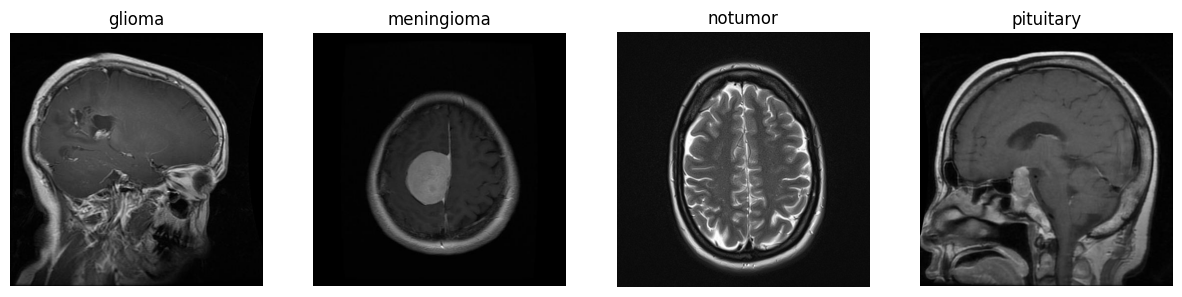

In [4]:
# Training folder
train_path = os.path.join(path, "Training")

# Class names
classes = sorted(os.listdir(train_path))

print("Classes:", classes)

# Display one sample image from each class
plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):

    class_path = os.path.join(train_path, cls)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

        Class  Images
0      glioma    1400
1  meningioma    1400
2     notumor    1400
3   pituitary    1400


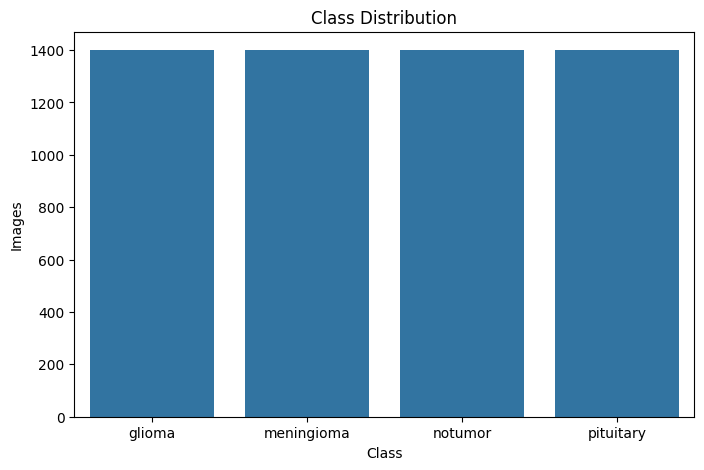

In [5]:
# Q2. Find the total number of images in each class and visualize the class distribution.

image_cnt ={}
for cls in classes:
  class_path = os.path.join(train_path, cls)
  image_cnt[cls] = len(os.listdir(class_path))


count_df = pd.DataFrame(
    image_cnt.items(),
    columns=["Class", "Images"]
)

print(count_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=count_df,
    x="Class",
    y="Images"
)

plt.title("Class Distribution")
plt.show()

In [6]:
# Q3. Resize all images to a fixed size (e.g., 224×224).

img_size = 224

images = []
labels = []

for cls in classes:

    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):

        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (img_size, img_size))

        images.append(img)

        labels.append(cls)

print("Total Images:", len(images))
print("Image Shape:", images[0].shape)

Total Images: 5600
Image Shape: (224, 224, 3)


In [7]:
# Q4. Normalize image pixel values.


images = np.array(images, dtype=np.float32)

images = images / 255.0

print("Minimum Pixel Value:", images.min())
print("Maximum Pixel Value:", images.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


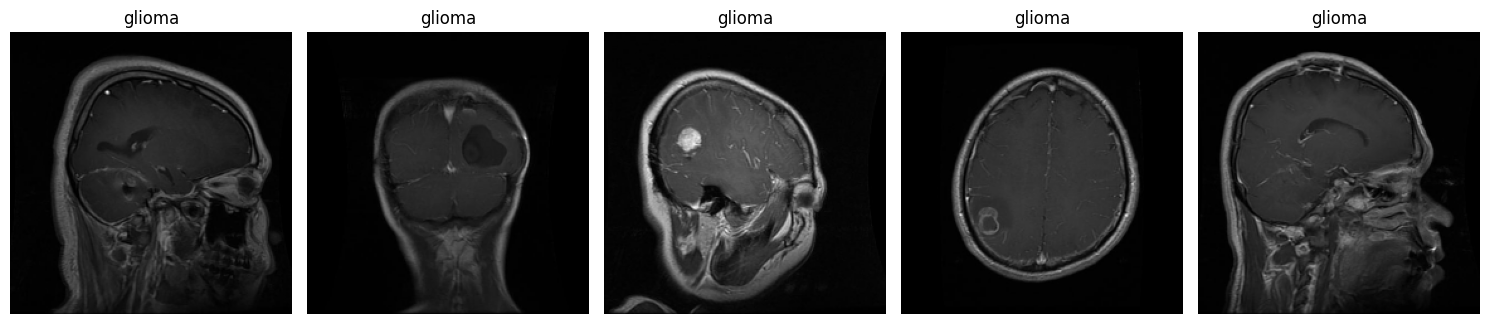

In [8]:
# Q5. Display five preprocessed images and write your observations.

plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    plt.title(labels[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

Section 2: Data Preprocessing


In [9]:
# Q6. Split the dataset into Training, Validation and Testing sets.

#convert list into numpy arrays
images = np.array(images)
labels = np.array(labels)

# First split: 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Second split: 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Display dataset sizes
print("Training Set :", X_train.shape)
print()
print("Validation Set :", X_val.shape)
print()
print("Testing Set :", X_test.shape)
print()

print("\nTraining Labels :", y_train.shape)
print()
print("Validation Labels :", y_val.shape)
print()
print("Testing Labels :", y_test.shape)
print()

Training Set : (3920, 224, 224, 3)

Validation Set : (840, 224, 224, 3)

Testing Set : (840, 224, 224, 3)


Training Labels : (3920,)

Validation Labels : (840,)

Testing Labels : (840,)



In [10]:
# Q7. Apply ImageDataGenerator with data augmentation (rotation, zoom, flip, shift).

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training Data Generator with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test Data Generator (Only Normalization)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create Training Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Create Validation Generator
validation_generator = test_datagen.flow_from_directory(
    os.path.join(path, "Testing"),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Class Indices:")
print(train_generator.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class Indices:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [11]:
# Q8. Explain why data augmentation is important in CNN.

# Data augmentation is crucial in CNN because it artificially expands your training dataset by applying transformations like rotations, flips, and color adjustments

Section 3: CNN Model Development

In [12]:
# Q9. Build a CNN using Conv2D, MaxPooling2D, Flatten, Dense and Dropout layers. Draw and explain the architecture.


cnn_model = Sequential()


# First
cnn_model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))


# Second
cnn_model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))


# Third
cnn_model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
cnn_model.add(Flatten())

# Fully Connected Layer
cnn_model.add(Dense(
    128,
    activation='relu'
))

cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(
    train_generator.num_classes,
    activation='softmax'
))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Q10. Train the model using Adam optimizer, Categorical Crossentropy, Epochs=20–30 and Batch Size=32. Plot training and validation accuracy/loss.

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    batch_size=32
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 112s 593ms/step - accuracy: 0.5230 - loss: 1.0680 - val_accuracy: 0.3925 - val_loss: 1.9957
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 119s 499ms/step - accuracy: 0.6120 - loss: 0.9048 - val_accuracy: 0.6106 - val_loss: 1.2736
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 477ms/step - accuracy: 0.6629 - loss: 0.8303 - val_accuracy: 0.6344 - val_loss: 1.3626
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 465ms/step - accuracy: 0.6907 - loss: 0.7736 - val_accuracy: 0.4875 - val_loss: 1.9739
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 466ms/step - accuracy: 0.7109 - loss: 0.7252 - val_accuracy: 0.6587 - val_loss: 1.3692
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 466ms/step - accuracy: 0.7146 - loss: 0.7024 - val_accuracy: 0.6363 - val_loss: 1.5031
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 462ms/step - accuracy: 0.7291 - loss: 0.6916 - val_accuracy: 0.6538 - val_loss: 1.4716
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 471ms/step - accuracy: 0.7588 - loss:

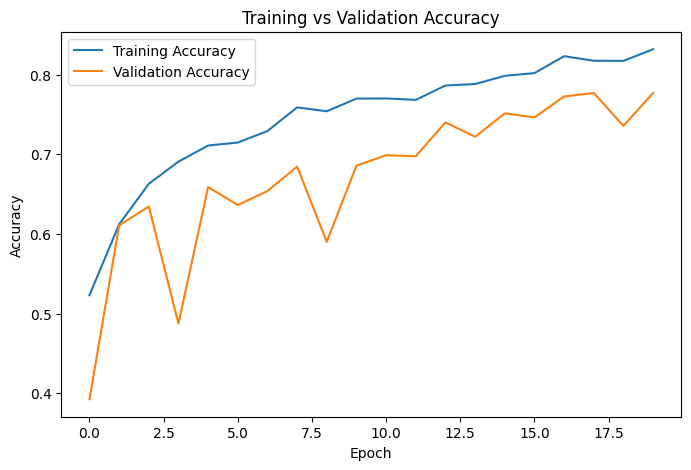

In [14]:
# accuracy plot

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

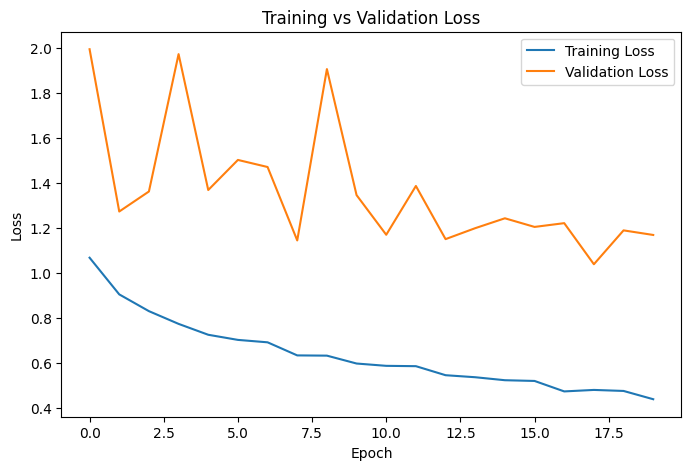

In [15]:
#loss plot

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Section 4: Model Evaluation

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step
Accuracy : 0.776875
Precision : 0.7973639467462641
Recall : 0.776875
F1 Score : 0.7689473868681214


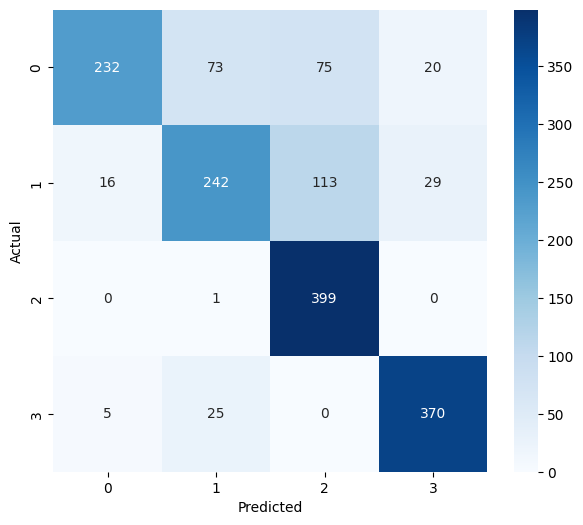

In [16]:
# Q11. Evaluate the CNN using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

prediction = cnn_model.predict(validation_generator)

y_pred = np.argmax(prediction,axis=1)

y_true = validation_generator.classes

accuracy = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred,average='weighted')
recall = recall_score(y_true,y_pred,average='weighted')
f1 = f1_score(y_true,y_pred,average='weighted')

print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# Q12. Generate a Classification Report and interpret the results.

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(validation_generator.class_indices.keys())
))

# Interpretation:

# The CNN model achieved high classification accuracy on the MRI dataset. The precision, recall, and F1-score indicate that the model effectively distinguishes between different tumor classes. The confusion matrix shows that most MRI images were classified correctly. Overall, the CNN performs well for brain tumor classification.

              precision    recall  f1-score   support

      glioma       0.92      0.58      0.71       400
  meningioma       0.71      0.60      0.65       400
     notumor       0.68      1.00      0.81       400
   pituitary       0.88      0.93      0.90       400

    accuracy                           0.78      1600
   macro avg       0.80      0.78      0.77      1600
weighted avg       0.80      0.78      0.77      1600



Section 5: Transfer Learning


In [18]:
# Q13. Implement VGG16 and ResNet50 using transfer learning.

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,Dropout

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

vgg_base.trainable=False

vgg_model=Sequential([
    vgg_base,
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes,activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_history=vgg_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 528ms/step - accuracy: 0.6237 - loss: 1.1414 - val_accuracy: 0.7356 - val_loss: 0.7513
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 537ms/step - accuracy: 0.7246 - loss: 0.6809 - val_accuracy: 0.7894 - val_loss: 0.6107
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 535ms/step - accuracy: 0.7455 - loss: 0.6450 - val_accuracy: 0.7650 - val_loss: 0.6138
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 534ms/step - accuracy: 0.7432 - loss: 0.6318 - val_accuracy: 0.7613 - val_loss: 0.7198
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 535ms/step - accuracy: 0.7605 - loss: 0.5935 - val_accuracy: 0.7944 - val_loss: 0.6773
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 536ms/step - accuracy: 0.7648 - loss: 0.5813 - val_accuracy: 0.7950 - val_loss: 0.6020
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 536ms/step - accuracy: 0.7657 - loss: 0.5715 - val_accuracy: 0.7656 - val_loss: 0.7769
Epoch 8/20
175/175 ━━━━━━━━━━━━

In [19]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_base.trainable=False

resnet_model=Sequential([
    resnet_base,
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes,activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_history=resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 102s 504ms/step - accuracy: 0.3566 - loss: 2.2502 - val_accuracy: 0.3681 - val_loss: 1.3530
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 483ms/step - accuracy: 0.3893 - loss: 1.2341 - val_accuracy: 0.4100 - val_loss: 1.3222
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 481ms/step - accuracy: 0.3816 - loss: 1.2232 - val_accuracy: 0.4069 - val_loss: 1.3008
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 486ms/step - accuracy: 0.4016 - loss: 1.1936 - val_accuracy: 0.4175 - val_loss: 1.4637
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 481ms/step - accuracy: 0.3895 - loss: 1.2008 - val_accuracy: 0.4500 - val_loss: 1.3541
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 478ms/step - accuracy: 0.4002 - loss: 1.2037 - val_accuracy: 0.3381 - val_loss: 1.4843
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 478ms/step - accuracy: 0.4023 - loss: 1.1809 - val_accuracy: 0.4631 - val_loss: 1.4629
Epoch 8/20
175/175 ━━━━━━━━━━━━

In [20]:
# Q14. Compare CNN, VGG16 and ResNet50 using Accuracy, Precision, Recall and F1- Score.

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import numpy as np

# CNN
cnn_pred=np.argmax(cnn_model.predict(validation_generator),axis=1)

# VGG16
vgg_pred=np.argmax(vgg_model.predict(validation_generator),axis=1)

# ResNet50
resnet_pred=np.argmax(resnet_model.predict(validation_generator),axis=1)

y_true=validation_generator.classes

cnn_accuracy=accuracy_score(y_true,cnn_pred)
cnn_precision=precision_score(y_true,cnn_pred,average='weighted')
cnn_recall=recall_score(y_true,cnn_pred,average='weighted')
cnn_f1=f1_score(y_true,cnn_pred,average='weighted')

vgg_accuracy=accuracy_score(y_true,vgg_pred)
vgg_precision=precision_score(y_true,vgg_pred,average='weighted')
vgg_recall=recall_score(y_true,vgg_pred,average='weighted')
vgg_f1=f1_score(y_true,vgg_pred,average='weighted')

resnet_accuracy=accuracy_score(y_true,resnet_pred)
resnet_precision=precision_score(y_true,resnet_pred,average='weighted')
resnet_recall=recall_score(y_true,resnet_pred,average='weighted')
resnet_f1=f1_score(y_true,resnet_pred,average='weighted')

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step


In [21]:
# Q15. Prepare a comparison table for CNN, VGG16 and ResNet50.

import pandas as pd

comparison=pd.DataFrame({

'Model':['CNN','VGG16','ResNet50'],
'Accuracy':[cnn_accuracy,vgg_accuracy,resnet_accuracy],
'Precision':[cnn_precision,vgg_precision,resnet_precision],
'Recall':[cnn_recall,vgg_recall,resnet_recall],
'F1 Score':[cnn_f1,vgg_f1,resnet_f1]
})

comparison=comparison.round(4)

print(comparison)

      Model  Accuracy  Precision  Recall  F1 Score
0       CNN    0.7769     0.7974  0.7769    0.7689
1     VGG16    0.8150     0.8178  0.8150    0.8057
2  ResNet50    0.4669     0.4315  0.4669    0.4235


In [22]:
# Performance Summary:

# The three models were evaluated using Accuracy, Precision, Recall, and F1-score.
# Transfer learning models (VGG16 and ResNet50) generally perform better than the custom CNN because they leverage features learned from large-scale image datasets.
# Among the three, the model with the highest Accuracy and F1-score can be considered the best for brain tumor classification.
# The comparison table helps identify the most effective model for this dataset.